# Robust Pairs Trading on the S&P 500

This notebook presents a weekly walk-forward pairs-trading backtest with point-in-time index membership, an internal validation period, transaction costs, and a buy-and-hold benchmark. The notebook explains the research decisions and diagnostics; the reusable implementation is in `pairs_trading/backtest.py`.

**Research question:** can a market-neutral relative-value strategy deliver useful out-of-sample risk-adjusted returns in the SPX universe?

## Financial intuition

Pairs trading buys the relatively cheap leg and shorts the relatively expensive leg. The signal is a standardized spread:

$$s_t = \log(y_t) - (\alpha + \beta \log(x_t)), \qquad z_t = \frac{s_t - \mu_s}{\sigma_s}.$$

The hedge ratio $\beta$ converts the two stocks into comparable long and short exposures. If $z_t$ is very negative, the strategy buys the spread (long $y$, short $x$); if it is very positive, it shorts the spread. A return is earned only if the spread moves back after entry.

Correlation describes short-run co-movement, while cointegration asks whether a linear combination of two price levels is stationary. Cointegration can still break after estimation, so the model also checks validation-period drift, volatility and mean crossings. A low market beta shows neutrality; it does not guarantee a positive return.

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

MARKET = "spx"
METHOD = "cointegration"
RECOMPUTE = False
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pairs_trading import (PairsBacktester, StrategyConfig, benchmark_returns,
                           load_market, performance_stats, plot_diagnostics,
                           plot_equity_drawdown, plot_parameter_sensitivity,
                           plot_spread)

RESULTS = ROOT / "results/spx_cointegration"

data = load_market(ROOT / "data" / "cache", MARKET)
config = StrategyConfig(selection_method=METHOD, min_price=5.0)
print(f"{data.prices.shape[1]:,} securities, {data.prices.index[0].date()} to {data.prices.index[-1].date()}")

1,355 securities, 1990-01-05 to 2018-11-30


## Research design and controls against bias

- Formation: 156 weeks.
- Internal validation: the final 52 formation weeks.
- Trading: the next 26 weeks, then repeat.
- Universe: current members with complete, clean formation data.
- Candidate restriction: same sector and market group.
- Trading: enter at +/-2 z, exit inside +/-0.5 z, stop at +/-3.5 z, and close after 12 weeks.
- Cost: 10 basis points per unit of turnover.

For each trading window, the implementation follows this sequence:

1. Reconstruct membership from the latest available historical index weights.
2. Remove incomplete, low-price and extreme-return histories.
3. Restrict comparisons to the same sector and require positive return correlation.
4. Estimate Engle-Granger cointegration in both directions on the training segment.
5. Apply a two-direction correction and Benjamini-Hochberg false-discovery-rate control.
6. Reject pairs with validation-period drift, volatility expansion or no mean crossing.
7. Refit the accepted relationship on the complete formation window and freeze it.
8. Trade only the following 26 weeks, then repeat with new historical information.

No stock is reused within a window. Each selected pair receives one twentieth of portfolio capital, so missing pair slots remain in cash rather than being redistributed. This lowers risk but also lowers capital utilization.

In [2]:
parameter_table = pd.Series({
    "Formation weeks": config.formation_weeks,
    "Validation weeks": config.validation_weeks,
    "Trading weeks": config.trading_weeks,
    "Maximum pairs": config.n_pairs,
    "Minimum return correlation": config.min_return_corr,
    "FDR level": config.fdr_alpha,
    "Entry z-score": config.entry_z,
    "Exit z-score": config.exit_z,
    "Stop z-score": config.stop_z,
    "Maximum holding weeks": config.max_holding_weeks,
    "Cost per unit turnover": config.fee,
}, name="Value").to_frame()
parameter_table

,Value
Formation weeks,156.000
Validation weeks,52.000
Trading weeks,26.000
Maximum pairs,20.000
Minimum return correlation,0.400
FDR level,0.100
Entry z-score,2.000
Exit z-score,0.500
Stop z-score,3.500
Maximum holding weeks,12.000


## Run or load the backtest

Set `RECOMPUTE=True` to repeat pair selection and trading from the cached market data. The default loads the saved deterministic result so the notebook opens quickly. Gross returns exclude the stated fee; net returns include it.

In [3]:
if RECOMPUTE:
    backtester = PairsBacktester(data, config)
    strategy_net, selections = backtester.run(progress=True)
    strategy_gross = PairsBacktester(data, replace(config, fee=0.0)).trade_selections(selections)
    benchmark = benchmark_returns(data, strategy_net.index)
else:
    saved = pd.read_csv(RESULTS / "weekly_returns.csv", index_col=0, parse_dates=True)
    strategy_net = saved["strategy_net"]
    strategy_gross = saved["strategy_gross"]
    benchmark = saved["benchmark"]

metrics = pd.DataFrame({
    "Strategy net": performance_stats(strategy_net, benchmark),
    "Strategy gross": performance_stats(strategy_gross, benchmark),
    "Benchmark": performance_stats(benchmark),
})
metrics

,Strategy net,Strategy gross,Benchmark
Annual volatility,0.005489,0.005492,0.164067
CAGR,0.000455,0.000959,0.071249
Market beta,-0.001522,-0.001518,NaN
Market correlation,-0.045488,-0.045336,NaN
Max drawdown,-0.021151,-0.019583,-0.562441
Positive weeks,0.190828,0.191568,0.565828
Sharpe (rf=0),0.085666,0.177356,0.502455
Sortino,0.067486,0.136913,0.652787
Total return,0.011905,0.025247,4.986220
Worst week,-0.007632,-0.007582,-0.181955


In [4]:
selected = pd.read_csv(RESULTS / "selected_pairs.csv", parse_dates=["trading_start"])
starts = data.prices.index[range(config.formation_weeks, len(data.prices) - 1,
                                 config.trading_weeks)]
counts = pd.Series(0, index=starts, dtype=int)
counts.update(selected.groupby("trading_start").size())

print(f"Selected pair instances: {len(selected):,}")
print(f"Average selected pairs per window: {counts.mean():.1f}")
print(f"Empty selection windows: {(counts == 0).sum()} of {len(counts)}")
display_columns = [column for column in
                   ["trading_start", "y", "x", "sector", "group", "q_value",
                    "distance", "half_life", "validation_mean_z"]
                   if column in selected]
selected[display_columns].head(10)

Selected pair instances: 145
Average selected pairs per window: 2.8
Empty selection windows: 14 of 52


,trading_start,y,x,sector,group,q_value,half_life,validation_mean_z
0,1993-01-01,45200Q UN Equity,CNP UN Equity,Utilities,all,0.045591,2.356630,-0.166042
1,1993-01-01,RBD UN Equity,MRK UN Equity,"Consumer, Non-cyclical",all,0.069631,4.025395,0.718592
2,1993-01-01,PCG UN Equity,UEP UN Equity,Utilities,all,0.017439,3.015240,1.275498
3,1993-07-02,D UN Equity,45200Q UN Equity,Utilities,all,0.094168,2.011805,-0.135359
4,1993-07-02,NEE UN Equity,XEL UN Equity,Utilities,all,0.083090,2.476152,0.210601
5,1993-07-02,263179Q US Equity,90457Q UN Equity,Financial,all,0.037960,2.210407,-0.650259
6,1993-07-02,DTE UN Equity,AEP UN Equity,Utilities,all,0.038696,2.818587,-0.928458
7,1993-07-02,611647Q UN Equity,204923Q US Equity,Industrial,all,0.052942,4.165231,0.712821
8,1993-07-02,UEP UN Equity,CEG UN Equity,Utilities,all,0.083090,3.603910,-1.035137
9,1993-07-02,RYC UN Equity,EMR UN Equity,Industrial,all,0.052942,3.464617,1.333471


## What the selected-pair fields mean

- `q_value` is the multiple-testing-adjusted cointegration significance level.
- `beta` is the frozen hedge ratio used to scale the short leg.
- `half_life` estimates the speed of mean reversion in weeks.
- `validation_mean_z` measures spread drift between training and validation.
- `validation_std_ratio` compares validation spread volatility with training volatility.
- `validation_crossings` counts how often the validation spread crossed its training mean.

These are formation-period diagnostics, not guarantees about the next trading window.

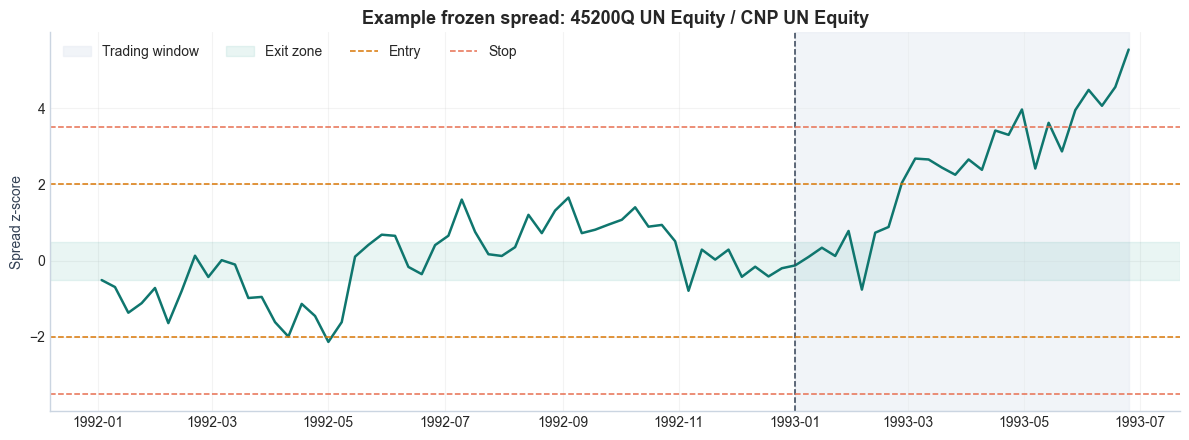

In [5]:
example = selected.iloc[0]
trade_start = example["trading_start"]
trade_position = data.prices.index.get_loc(trade_start)
view = slice(max(0, trade_position - config.validation_weeks),
             min(len(data.prices), trade_position + config.trading_weeks))
spread = (np.log(data.prices[example["y"]].iloc[view])
          - example["alpha"]
          - example["beta"] * np.log(data.prices[example["x"]].iloc[view]))
z_score = (spread - example["mean"]) / example["sigma"]

_ = plot_spread(z_score, trade_start, config,
                f"Example frozen spread: {example['y']} / {example['x']}")

In [6]:
active = (strategy_net.abs() + strategy_gross.abs()) > 1e-12
midpoint = len(strategy_net) // 2
diagnostics = pd.Series({
    "Selected pair instances": len(selected),
    "Average pairs per window": counts.mean(),
    "Empty selection windows": (counts == 0).sum(),
    "Active-week share": active.mean(),
    "Positive active weeks": (strategy_net[active] > 0).mean(),
    "Average half-life (weeks)": selected["half_life"].mean(),
    "Gross-to-net wealth drag": (1 + strategy_gross).prod() - (1 + strategy_net).prod(),
    "First-half net return": (1 + strategy_net.iloc[:midpoint]).prod() - 1,
    "Second-half net return": (1 + strategy_net.iloc[midpoint:]).prod() - 1,
}, name="Diagnostic")
diagnostics.to_frame()

,Diagnostic
Selected pair instances,145.000000
Average pairs per window,2.788462
Empty selection windows,14.000000
Active-week share,0.390533
Positive active weeks,0.488636
Average half-life (weeks),3.469209
Gross-to-net wealth drag,0.013343
First-half net return,0.011112
Second-half net return,0.000784


In [7]:
method_comparison = {}
for method in ["cointegration", "distance"]:
    result = pd.read_csv(ROOT / f"results/spx_{method}/metrics.csv", index_col=0)
    method_comparison[method.title()] = result["Strategy net"]
method_comparison = pd.DataFrame(method_comparison).T
method_comparison[["Total return", "CAGR", "Sharpe (rf=0)",
                   "Max drawdown", "Market beta"]]

,Total return,CAGR,Sharpe (rf=0),Max drawdown,Market beta
Cointegration,0.011905,0.000455,0.085666,-0.021151,-0.001522
Distance,-0.001820,-0.000070,0.000553,-0.057315,0.008148


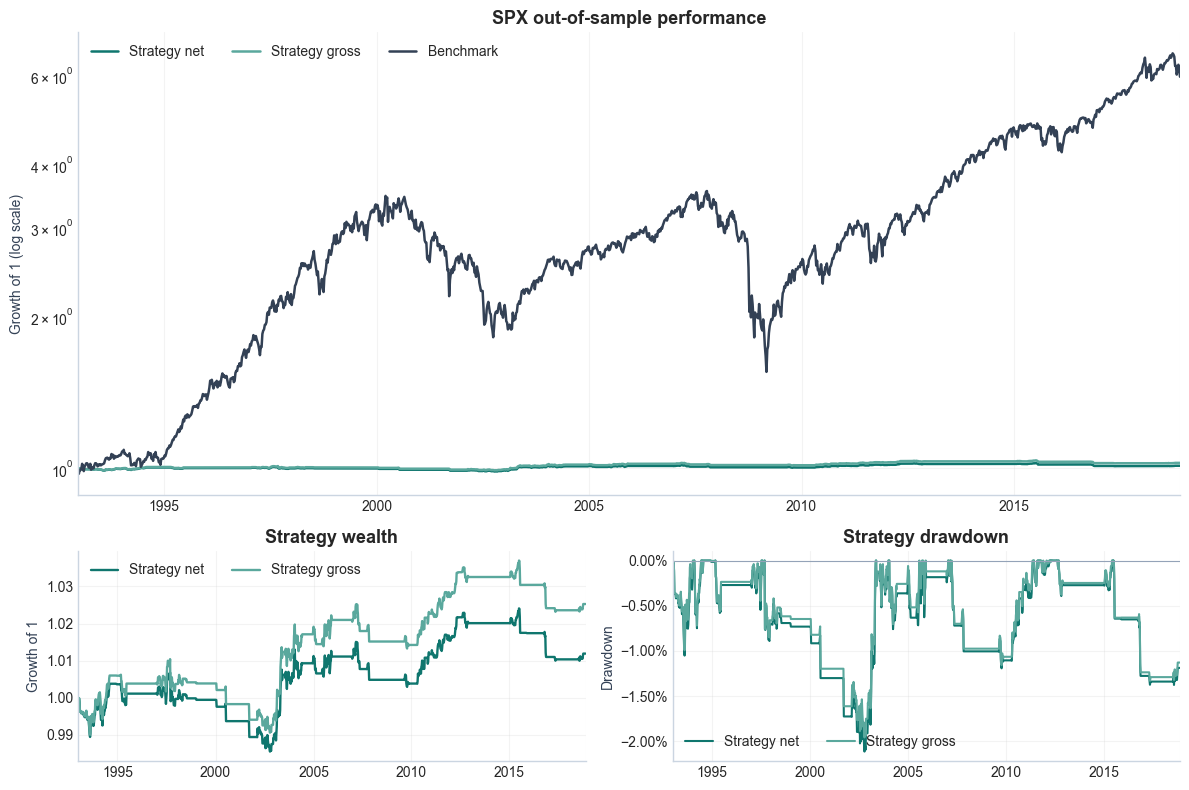

In [8]:
returns = pd.DataFrame({
    "Strategy net": strategy_net,
    "Strategy gross": strategy_gross,
    "Benchmark": benchmark,
})
_ = plot_equity_drawdown(returns, f"{MARKET.upper()} out-of-sample performance")

## Stability through time

A positive full-sample return can hide long weak periods. Annual returns, rolling Sharpe and selected-pair counts show whether performance and opportunity availability are stable. The rolling Sharpe is descriptive because overlapping 52-week windows are not independent.

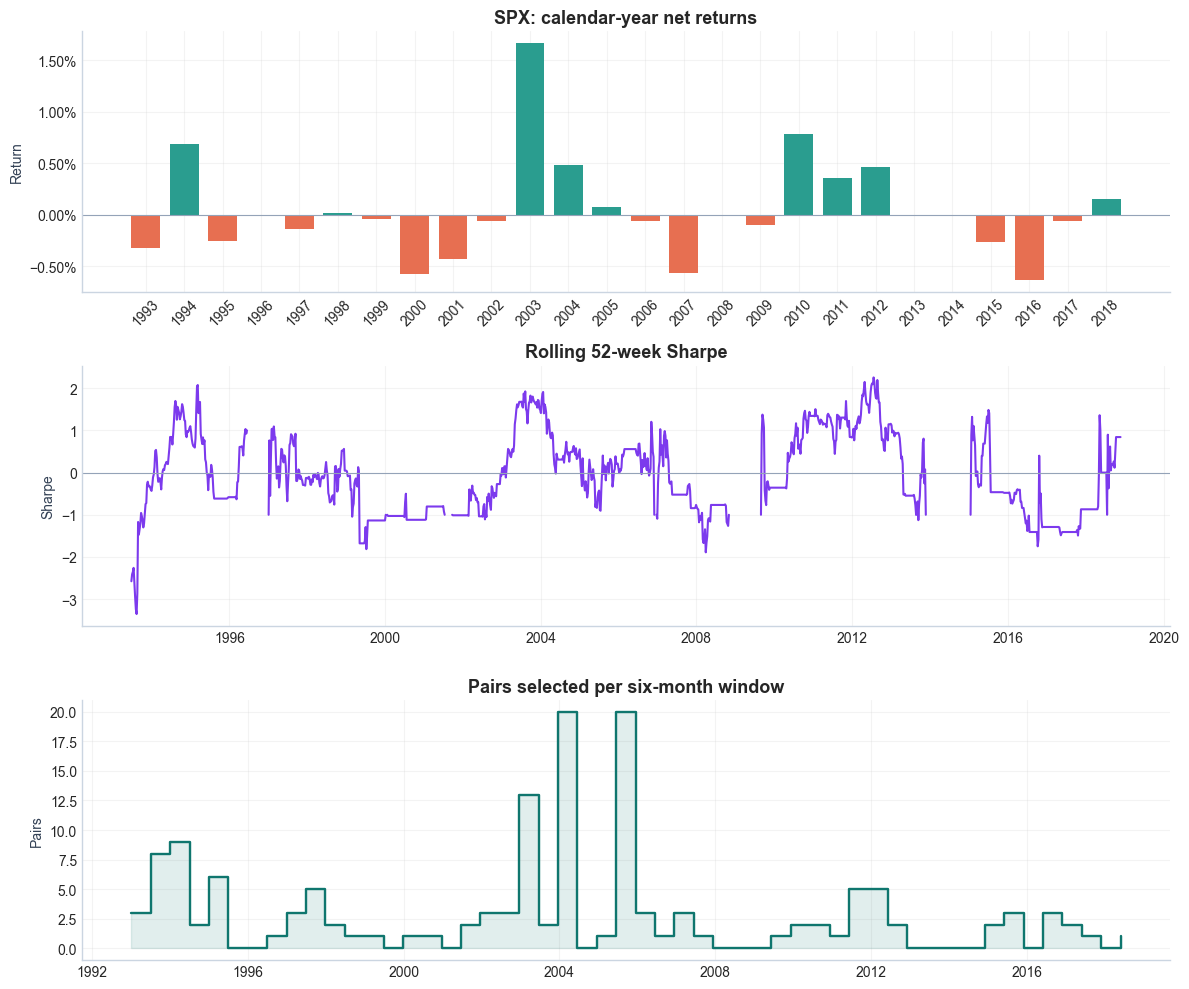

In [9]:
_, annual_returns, rolling_sharpe = plot_diagnostics(
    strategy_net, benchmark, counts, MARKET.upper()
)

## Trading-rule sensitivity

The entry-exit matrix restores the original notebook's useful Sharpe diagnostic using the improved backtest engine. Pair selection remains fixed, while the trading layer is rerun for each parameter combination. The cost panel shows how quickly implementation costs consume the edge, and the final table changes one assumption at a time.

This is **descriptive sensitivity analysis, not parameter optimization**. Every value reuses the same complete evaluation period, so the highest Sharpe cell cannot be presented as a proven improvement or used to replace the baseline without a nested walk-forward test.

Exit z-score,0.000000,0.500000,1.000000
Entry z-score,,,
1.500000,0.18,0.28,0.31
2.000000,0.12,0.09,0.08
2.500000,0.09,0.03,0.08


,Total return,CAGR,Sharpe (rf=0),Max drawdown
Cost per unit turnover (bps),,,,
0,+2.52%,+0.10%,0.18,-1.96%
5,+1.86%,+0.07%,0.13,-2.04%
10,+1.19%,+0.05%,0.09,-2.12%
20,-0.13%,-0.00%,-0.01,-2.27%


,Total return,CAGR,Sharpe (rf=0),Max drawdown,Annual volatility
Baseline,0.011905,0.000455,0.085666,-0.021151,0.005489
Entry 1.5,0.052553,0.001972,0.276697,-0.022750,0.007214
Entry 2.5,0.002739,0.000105,0.025677,-0.024902,0.004491
Exit 0.75,0.013478,0.000515,0.097068,-0.021151,0.005458
Stop 4.0,0.013604,0.000520,0.090101,-0.022496,0.005965
Hold 20 weeks,0.017956,0.000685,0.124901,-0.019999,0.005606
Fee 5 bps,0.018554,0.000707,0.131547,-0.020368,0.005490
Fee 20 bps,-0.001266,-0.000049,-0.006120,-0.022717,0.005494


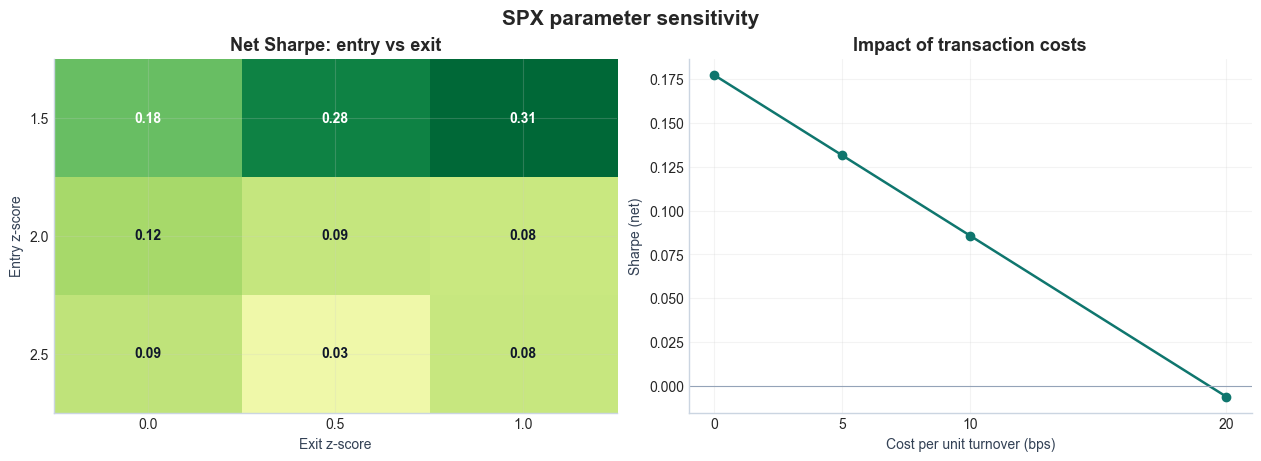

In [10]:
start_positions = range(config.formation_weeks, len(data.prices) - 1, config.trading_weeks)
selection_map = {
    position: selected.loc[selected["trading_start"].eq(data.prices.index[position])].drop(columns="trading_start")
    for position in start_positions
}
def evaluate_scenario(**changes):
    scenario_config = replace(config, **changes)
    scenario_returns = PairsBacktester(data, scenario_config).trade_selections(selection_map)
    return performance_stats(scenario_returns)


entry_values = [1.5, 2.0, 2.5]
exit_values = [0.0, 0.5, 1.0]
sharpe_grid = pd.DataFrame(
    [[evaluate_scenario(entry_z=entry, exit_z=exit_)["Sharpe (rf=0)"]
      for exit_ in exit_values] for entry in entry_values],
    index=pd.Index(entry_values, name="Entry z-score"),
    columns=pd.Index(exit_values, name="Exit z-score"),
)
fee_table = pd.DataFrame({
    fee_bps: evaluate_scenario(fee=fee_bps / 10_000)
    for fee_bps in [0, 5, 10, 20]
}).T
fee_table.index.name = "Cost per unit turnover (bps)"
plot_parameter_sensitivity(sharpe_grid, fee_table, f"{MARKET.upper()} parameter sensitivity")
display(sharpe_grid.style.format("{:.2f}").set_caption("Net Sharpe matrix"))
display(fee_table[["Total return", "CAGR", "Sharpe (rf=0)", "Max drawdown"]]
        .style.format({"Total return": "{:+.2%}", "CAGR": "{:+.2%}",
                       "Sharpe (rf=0)": "{:.2f}", "Max drawdown": "{:.2%}"})
        .set_caption("Transaction-cost sensitivity"))

scenarios = {
    "Baseline": {},
    "Entry 1.5": {"entry_z": 1.5},
    "Entry 2.5": {"entry_z": 2.5},
    "Exit 0.75": {"exit_z": 0.75},
    "Stop 4.0": {"stop_z": 4.0},
    "Hold 20 weeks": {"max_holding_weeks": 20},
    "Fee 5 bps": {"fee": 0.0005},
    "Fee 20 bps": {"fee": 0.0020},
}
sensitivity = pd.DataFrame({
    label: evaluate_scenario(**changes) for label, changes in scenarios.items()
}).T
assert np.isclose(sensitivity.loc["Baseline", "Total return"], metrics.loc["Total return", "Strategy net"])
sensitivity[["Total return", "CAGR", "Sharpe (rf=0)",
             "Max drawdown", "Annual volatility"]]

## Result interpretation

### What worked

- The net total return is **+1.19%**, compared with **+2.52% gross**. Maximum drawdown is only **-2.12%**, and market beta is approximately **-0.002**. The strategy therefore achieved low market exposure and limited portfolio loss.
- The improved result is materially better than the original notebook's negative result, mainly because unstable pairs are rejected and unused capacity stays in cash.

### What did not work well

- Sharpe is only **0.09** and CAGR is about **0.05%**. Economically, this is too small to compensate for model, financing and operational risk.
- Only **145 pair instances** are selected across 52 windows: **2.8 pairs per window** on average, with **14 empty windows**. The very low volatility partly reflects low capital utilization rather than unusually accurate forecasts.
- Transaction costs reduce terminal wealth by about **1.33 percentage points**, more than half of the gross gain. At 20 basis points per unit turnover, this sensitivity turns slightly negative.
- The first half earns about **+1.11%** and the second half only about **+0.08%**. The edge is not stable through time.
- Lowering entry from 2.0 to 1.5 improves the historical result in this diagnostic, but choosing it after observing the full sample would be overfitting. It is a hypothesis for a new validation design, not the new official parameter.

## Model-improvement roadmap

1. **Freeze the current baseline.** Keep these results unchanged as the reference model.
2. **Use nested walk-forward tuning.** Choose entry, exit, stop and holding rules only inside each formation period; evaluate once in the following untouched window. Prefer a stable parameter region over the single best Sharpe.
3. **Add a trade ledger.** Record every entry, exit, holding period, stop, gross P&L and cost. This allows attribution by sector, pair, regime and exit reason.
4. **Improve execution realism.** Trade at the next executable price and include bid-ask spread, borrow fee and availability, dividends, financing and cash collateral yield.
5. **Refresh the data.** Freeze the specification before testing post-2018 point-in-time constituents and corporate actions. This is the most important test of whether the edge still exists.
6. **Test modest extensions only after the baseline.** Candidates include time-varying hedge ratios, market-volatility regime filters and volatility-scaled pair allocation. Each extension needs an ablation test against the baseline.
7. **Paper trade before live use.** Monitor data quality, signal latency, rejected orders and realized slippage for several months.

## Conclusion

This is evidence of effective filtering and market-neutral risk control, not evidence of a strong tradable alpha. The next research priority is an untouched modern sample with realistic execution, not further optimization on 1993-2018 data.